In [37]:
import numpy as np
import matplotlib.pyplot as plt 

In [38]:
def generate_data(num_samples):
    X = np.random.randn(num_samples, 1)*10
    y = 3 * X + 7 + np.random.randn(num_samples,1)
    return X, y

In [39]:
X, y = generate_data(50)

In [40]:
def compute_loss(y_true, y_pred):
    return np.mean((y_true-y_pred)**2)

In [138]:
theta_ = np.random.randn(X.shape[1]+1,1)

In [ ]:
class MomentumGD:
    def __init__(self, parameters, epochs = 100, lr = 0.01, beta = 0.5, print_on_step=None):
        self.n_epochs = epochs
        self.lr = lr
        self.beta = beta
        self.theta_ = parameters 
        self.pairs = [parameters.copy().reshape(-1)]
        self.print_on_step = print_on_step
        self.velocity = parameters.copy() #np.zeros(self.theta_.shape)

        self.loss_history = []


    def optimize(self, X, y):
        n_points, n_features = X.shape
        X = np.c_[np.ones((n_points,1)),X]

        for epoch in range(1,1+self.n_epochs):
            y_pred = np.dot(X, self.theta_)

            error = y - y_pred
            loss = compute_loss(y,y_pred)
            
            gradient = - (2/n_points) * np.dot(X.T,error)

            self.velocity = self.beta * self.velocity + (1 - self.beta) * gradient


            self.theta_ -= self.lr * self.velocity

            self.pairs.append(self.theta_.copy().reshape(-1))

            if self.print_on_step:
                if epoch%self.print_on_step == 0:
                    print(f"Epoch: {epoch}, Loss: {loss:.4f}")

            self.loss_history.append(loss)


In [140]:
momentum_gd = MomentumGD(theta_, 100, 0.01, 0.9, 10)

In [141]:
momentum_gd.optimize(X,y)

Epoch: 10, Loss: 83.9979
Epoch: 20, Loss: 91.6335
Epoch: 30, Loss: 31.9891
Epoch: 40, Loss: 21.9450
Epoch: 50, Loss: 12.1576
Epoch: 60, Loss: 7.7752
Epoch: 70, Loss: 5.2127
Epoch: 80, Loss: 3.6301
Epoch: 90, Loss: 2.7427
Epoch: 100, Loss: 2.1717


In [166]:
d = y - np.dot(X_aug,np.c_[pairs[:,0],pairs[:,1]].T)


In [157]:
np.c_[pairs[:,0],pairs[:,1]].shape

(101, 2)

In [159]:
Y_preds = X_aug @ Theta_grid.T
print(Y_preds.shape,y.shape)

(50, 10000) (50, 1)


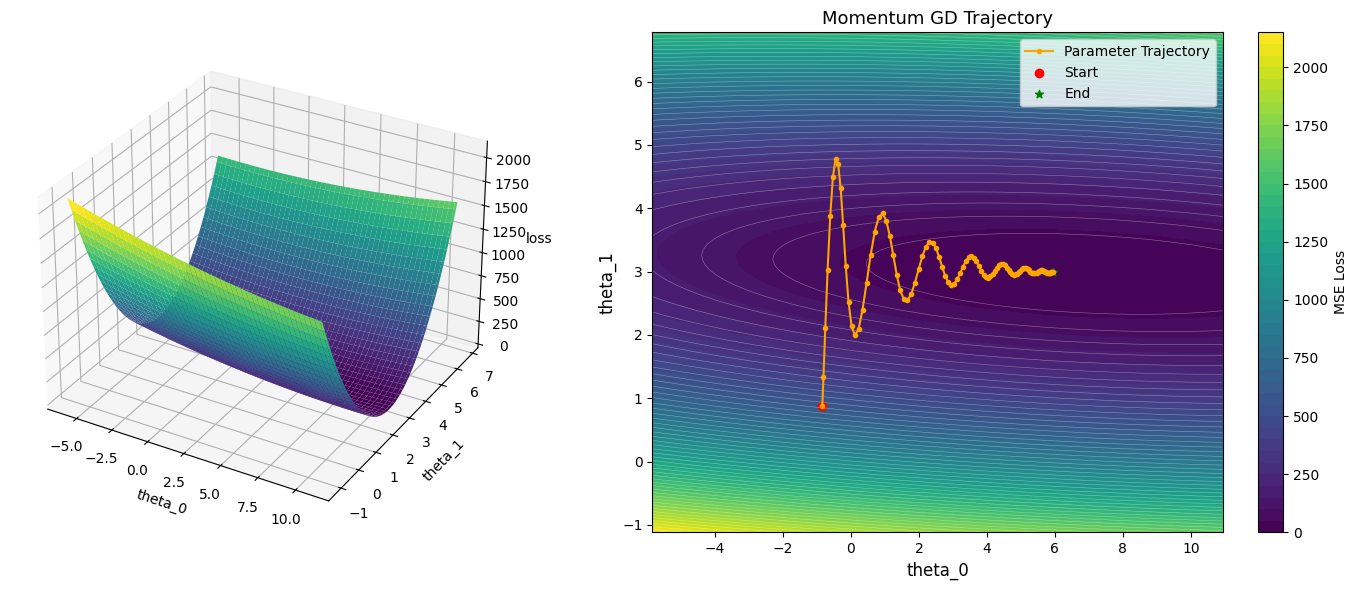

In [179]:
pairs = np.array(momentum_gd.pairs)  
n_points = X.shape[0]
X_aug = np.c_[np.ones((n_points, 1)), X]  

theta0_vals = np.linspace(pairs[:, 0].min() - 5, pairs[:, 0].max() + 5, 100)
theta1_vals = np.linspace(pairs[:, 1].min() - 2, pairs[:, 1].max() + 2, 100)
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)  

Theta_grid = np.column_stack([T0.ravel(), T1.ravel()])

Y_preds = X_aug @ Theta_grid.T

Loss = np.mean((y - Y_preds) ** 2, axis=0).reshape(T0.shape)

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(121, projection='3d')

ax1.plot_surface(T0, T1, Loss, cmap='viridis')
ax1.set_xlabel('theta_0')
ax1.set_ylabel('theta_1')
ax1.set_zlabel('loss')

ax2 = fig.add_subplot(122)

contour_filled = ax2.contourf(T0, T1, Loss, levels=50, cmap='viridis')
ax2.contour(T0, T1, Loss, levels=60, colors='white', linewidths=0.4, alpha=0.4)
plt.colorbar(contour_filled, ax=ax2, label='MSE Loss')


ax2.plot(pairs[:, 0], pairs[:, 1], color='orange', linewidth=1.5, marker='o', markersize=3, label='Parameter Trajectory')

ax2.scatter(*pairs[0],  color='red', label='Start')
ax2.scatter(*pairs[-1], color='green',   marker='*', label='End')

ax2.set_xlabel('theta_0',   fontsize=12)
ax2.set_ylabel('theta_1', fontsize=12)
ax2.set_title('Momentum GD Trajectory', fontsize=13)
ax2.legend()
plt.tight_layout()
plt.show()

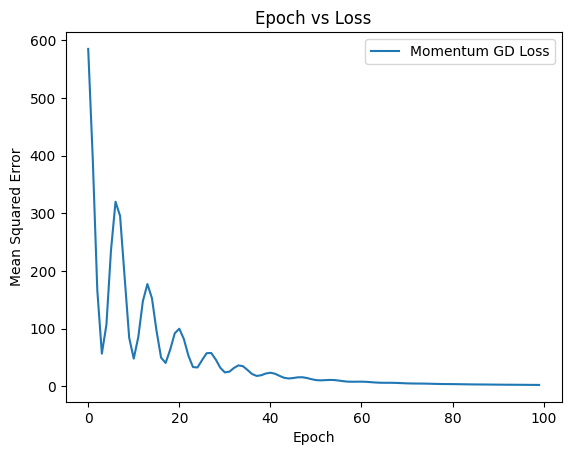

In [143]:
plt.plot(momentum_gd.loss_history,label="Momentum GD Loss")
plt.title("Epoch vs Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.show()